In [77]:
%pip install pandas numpy matplotlib seaborn geopandas shapely statsmodels

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd
from shapely import wkt
import re
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import statsmodels.api as sm

Note: you may need to restart the kernel to use updated packages.


In [78]:
ridership = pd.read_csv("resources/ridership_by_station.csv", dtype={'station_id': str})
ridership.head()

,station_id,stationname,date,daytype,rides
0,41280,Jefferson Park,12/22/2017,W,6104
1,41000,Cermak-Chinatown,12/18/2017,W,3636
2,40280,Central-Lake,12/02/2017,A,1270
3,40140,Dempster-Skokie,12/19/2017,W,1759
4,40690,Dempster,12/03/2017,U,499


In [79]:
ridership['date'] = pd.to_datetime(ridership['date'])
ridership['daytype'] = ridership['daytype'].astype('category')
ridership['rides'] = pd.to_numeric(ridership['rides'], errors='coerce')
ridership['station_id'] = pd.to_numeric(ridership['station_id'], errors='coerce')
ridership.info()

<class 'pandas.DataFrame'>
RangeIndex: 1298399 entries, 0 to 1298398
Data columns (total 5 columns):
 #   Column       Non-Null Count    Dtype         
---  ------       --------------    -----         
 0   station_id   1298399 non-null  int64         
 1   stationname  1298399 non-null  str           
 2   date         1298399 non-null  datetime64[us]
 3   daytype      1298399 non-null  category      
 4   rides        1298399 non-null  int64         
dtypes: category(1), datetime64[us](1), int64(2), str(1)
memory usage: 40.9 MB


In [80]:
ridership.head()

,station_id,stationname,date,daytype,rides
0,41280,Jefferson Park,2017-12-22,W,6104
1,41000,Cermak-Chinatown,2017-12-18,W,3636
2,40280,Central-Lake,2017-12-02,A,1270
3,40140,Dempster-Skokie,2017-12-19,W,1759
4,40690,Dempster,2017-12-03,U,499


In [81]:
station_info = pd.read_csv("resources/system_info.csv")
station_info.head()

,STOP_ID,DIRECTION_ID,STOP_NAME,STATION_NAME,STATION_DESCRIPTIVE_NAME,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,Location
0,30263,E,Oak Park (63rd-bound),Oak Park,Oak Park (Green Line),41350,False,False,False,True,False,False,False,False,False,"(41.886988, -87.793783)"
1,30152,W,Central Park (54th/Cermak-bound),Central Park,Central Park (Pink Line),40780,True,False,False,False,False,False,False,True,False,"(41.853839, -87.714842)"
2,30148,S,Granville (95th-bound),Granville,Granville (Red Line),40760,True,True,False,False,False,False,False,False,False,"(41.993664, -87.659202)"
3,30044,N,Cumberland (O'Hare-bound),Cumberland,Cumberland (Blue Line),40230,True,False,True,False,False,False,False,False,False,"(41.984246, -87.838028)"
4,30007,N,Quincy/Wells (Inner Loop),Quincy/Wells,"Quincy/Wells (Brown, Orange, Purple & Pink lines)",40040,True,False,False,False,False,True,False,True,True,"(41.878723, -87.63374)"


In [82]:
station_info['DIRECTION_ID'] = station_info['DIRECTION_ID'].astype('category')
station_info['MAP_ID'] = station_info['MAP_ID'].astype(int)
for col in station_info.select_dtypes(include=['bool']).columns:
    station_info[col] = station_info[col].astype(int)

station_info[['latitude', 'longitude']] = station_info['Location'].str.strip().str.strip('()').str.split(', ', expand=True)
station_info['latitude'] = pd.to_numeric(station_info['latitude'].str.strip())
station_info['longitude'] = pd.to_numeric(station_info['longitude'].str.strip())
station_info = station_info[['STATION_NAME', 'DIRECTION_ID', 'MAP_ID', 'ADA', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude']]
station_info.head()

,STATION_NAME,DIRECTION_ID,MAP_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,latitude,longitude
0,Oak Park,E,41350,0,0,0,1,0,0,0,0,0,41.886988,-87.793783
1,Central Park,W,40780,1,0,0,0,0,0,0,1,0,41.853839,-87.714842
2,Granville,S,40760,1,1,0,0,0,0,0,0,0,41.993664,-87.659202
3,Cumberland,N,40230,1,0,1,0,0,0,0,0,0,41.984246,-87.838028
4,Quincy/Wells,N,40040,1,0,0,0,0,1,0,1,1,41.878723,-87.633740


In [83]:
#Identify which stations have conflicting ADA status (i.e. part of station or certain lines are ADA compliant while others aren't)
grouped_ada = station_info.groupby('MAP_ID')['ADA'].apply(lambda x: x.unique())
conflicting_stations = grouped_ada[grouped_ada.apply(lambda x: 0 in x and 1 in x)].index.tolist()

print("STATION_NAMEs with conflicting ADA values:", conflicting_stations)

STATION_NAMEs with conflicting ADA values: []


In [84]:
agg_dict = {
    'STATION_NAME': 'first',
    'latitude': 'first',
    'longitude': 'first',
    'DIRECTION_ID': lambda x: tuple(x.unique()),
    'ADA': 'max',
    'RED': 'max',
    'BLUE': 'max',
    'G': 'max',
    'BRN': 'max',
    'P': 'max',
    'Y': 'max',
    'Pnk': 'max',
    'O': 'max'
}

si_aggregated = station_info.groupby('MAP_ID').agg(agg_dict).reset_index()
si_aggregated.head()

,MAP_ID,STATION_NAME,latitude,longitude,DIRECTION_ID,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O
0,40010,Austin,41.870851,-87.776812,"(W, E)",0,0,1,0,0,0,0,0,0
1,40020,Harlem/Lake,41.886848,-87.803176,"(W, E)",1,0,0,1,0,0,0,0,0
2,40030,Pulaski,41.885412,-87.725404,"(W, E)",1,0,0,1,0,0,0,0,0
3,40040,Quincy/Wells,41.878723,-87.633740,"(N, S)",1,0,0,0,1,1,0,1,1
4,40050,Davis,42.047710,-87.683543,"(N, S)",1,0,0,0,0,1,0,0,0


In [85]:
#Turn direction into a dummy variable
direction_dummies = si_aggregated['DIRECTION_ID'].apply(lambda x: '|'.join(map(str, x))).str.get_dummies()
si_aggregated = si_aggregated.join(direction_dummies).drop(columns=['DIRECTION_ID'])
si_aggregated['N/S'] = si_aggregated['N'] | si_aggregated['S']
si_aggregated['E/W'] = si_aggregated['E'] | si_aggregated['W']
si_aggregated = si_aggregated.drop(columns=['N', 'S', 'E', 'W'])
si_aggregated.head()

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0


In [86]:
station_ridership = pd.merge(ridership, si_aggregated, left_on='station_id', right_on='MAP_ID', how='left')
display(station_ridership)

,station_id,stationname,date,daytype,rides,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,41280,Jefferson Park,2017-12-22,W,6104,41280.0,Jefferson Park,41.970634,-87.760892,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
1,41000,Cermak-Chinatown,2017-12-18,W,3636,41000.0,Cermak-Chinatown,41.853206,-87.630968,1.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
2,40280,Central-Lake,2017-12-02,A,1270,40280.0,Central,41.887389,-87.765650,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
3,40140,Dempster-Skokie,2017-12-19,W,1759,40140.0,Dempster-Skokie,42.038951,-87.751919,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
4,40690,Dempster,2017-12-03,U,499,40690.0,Dempster,42.041655,-87.681602,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1298394,41710,Damen-Lake,2025-11-26,W,773,41710.0,Damen,41.884974,-87.676891,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298395,41710,Damen-Lake,2025-11-27,U,300,41710.0,Damen,41.884974,-87.676891,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298396,41710,Damen-Lake,2025-11-28,W,532,41710.0,Damen,41.884974,-87.676891,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
1298397,41710,Damen-Lake,2025-11-29,A,287,41710.0,Damen,41.884974,-87.676891,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0


In [87]:
start_date = pd.to_datetime('2000-01-01')
station_ridership['days_since_2000'] = (station_ridership['date'] - start_date).dt.days

#Calculate month (as integer)
station_ridership['month'] = station_ridership['date'].dt.month

#Calculate year
station_ridership['year'] = station_ridership['date'].dt.year

#Define a function to get the season
def get_season(month):
    if month in [12, 1, 2]:
        return 'Winter'
    elif month in [3, 4, 5]:
        return 'Spring'
    elif month in [6, 7, 8]:
        return 'Summer'
    else:
        return 'Fall'

#Apply the function to get the season column
station_ridership['season'] = station_ridership['month'].apply(get_season)

#Display the first few rows with the new columns
print(station_ridership[['date', 'days_since_2000', 'season', 'month', 'year']].head())

        date  days_since_2000  season  month  year
0 2017-12-22             6565  Winter     12  2017
1 2017-12-18             6561  Winter     12  2017
2 2017-12-02             6545  Winter     12  2017
3 2017-12-19             6562  Winter     12  2017
4 2017-12-03             6546  Winter     12  2017


In [88]:
#Add season as dummy variable
season_dummies = pd.get_dummies(station_ridership['season'], prefix='season', drop_first=True)
station_ridership = pd.concat([station_ridership, season_dummies], axis=1)
season_dummies = season_dummies.astype(int)
station_ridership.head()
station_ridership.columns

Index(['station_id', 'stationname', 'date', 'daytype', 'rides', 'MAP_ID',
       'STATION_NAME', 'latitude', 'longitude', 'ADA', 'RED', 'BLUE', 'G',
       'BRN', 'P', 'Y', 'Pnk', 'O', 'N/S', 'E/W', 'days_since_2000', 'month',
       'year', 'season', 'season_Spring', 'season_Summer', 'season_Winter'],
      dtype='str')

In [89]:
#Add variable that represents days since initial school shutdown in Chicago for COVID
shutdown_date = pd.to_datetime('2020-03-13')
station_ridership['post_shutdown'] = (station_ridership['date'] >= shutdown_date).astype(int)
station_ridership.head()

,station_id,stationname,date,daytype,rides,MAP_ID,STATION_NAME,latitude,longitude,ADA,...,N/S,E/W,days_since_2000,month,year,season,season_Spring,season_Summer,season_Winter,post_shutdown
0,41280,Jefferson Park,2017-12-22,W,6104,41280.0,Jefferson Park,41.970634,-87.760892,1.0,...,1.0,0.0,6565,12,2017,Winter,False,False,True,0
1,41000,Cermak-Chinatown,2017-12-18,W,3636,41000.0,Cermak-Chinatown,41.853206,-87.630968,1.0,...,1.0,0.0,6561,12,2017,Winter,False,False,True,0
2,40280,Central-Lake,2017-12-02,A,1270,40280.0,Central,41.887389,-87.765650,1.0,...,0.0,1.0,6545,12,2017,Winter,False,False,True,0
3,40140,Dempster-Skokie,2017-12-19,W,1759,40140.0,Dempster-Skokie,42.038951,-87.751919,1.0,...,1.0,0.0,6562,12,2017,Winter,False,False,True,0
4,40690,Dempster,2017-12-03,U,499,40690.0,Dempster,42.041655,-87.681602,0.0,...,1.0,0.0,6546,12,2017,Winter,False,False,True,0


In [90]:
#Identify rows with missing latitude or longitude
missing_coords_df = station_ridership[station_ridership['latitude'].isnull() | station_ridership['longitude'].isnull()]

#Get unique station names with missing coordinates, excluding NaN values
unique_stations_missing_coords = missing_coords_df['stationname'].dropna().unique()

if len(unique_stations_missing_coords) == 0:
    print("No stations found with missing latitude or longitude values.")
else:
    print("Stations with missing latitude or longitude values and their date range:")
    for station_name in unique_stations_missing_coords:
        # Filter for the current station and missing coordinates using 'stationname'
        station_missing_data = missing_coords_df[missing_coords_df['stationname'] == station_name]

        # Get the first and last date for this station's missing coordinates
        first_date = station_missing_data['date'].min()
        last_date = station_missing_data['date'].max()

        print(f"{station_name}, {first_date.strftime('%Y-%m-%d')} through {last_date.strftime('%Y-%m-%d')}")

Stations with missing latitude or longitude values and their date range:
Randolph/Wabash, 2001-01-01 through 2019-01-31
Madison/Wabash, 2001-01-01 through 2018-01-01
Washington/State, 2001-01-01 through 2009-01-31
Homan, 2001-07-01 through 2001-07-31


<Axes: >

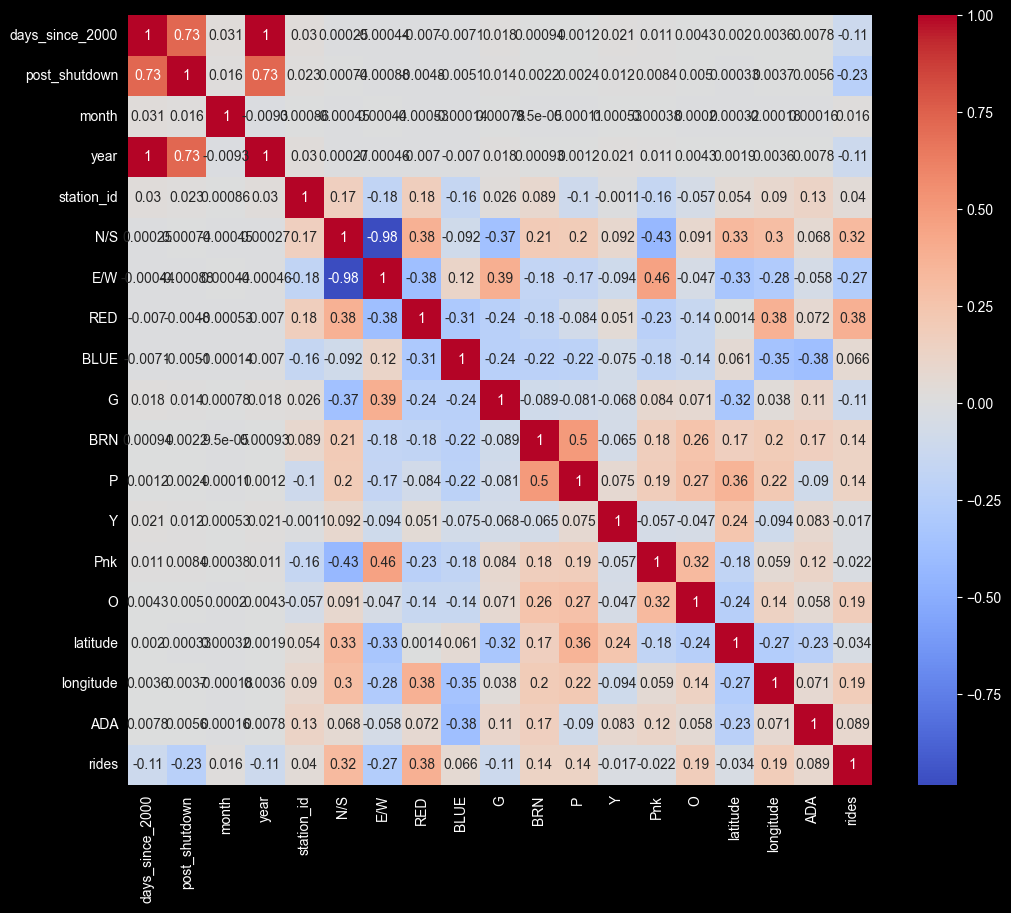

In [91]:
columns_for_splom = ['days_since_2000', 'post_shutdown', 'month', 'year', 'station_id', 'N/S', 'E/W', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude', 'ADA', 'rides']

#See correlations
plt.figure(figsize=(12,10))
sns.heatmap(station_ridership[columns_for_splom].corr(), annot=True, cmap='coolwarm')

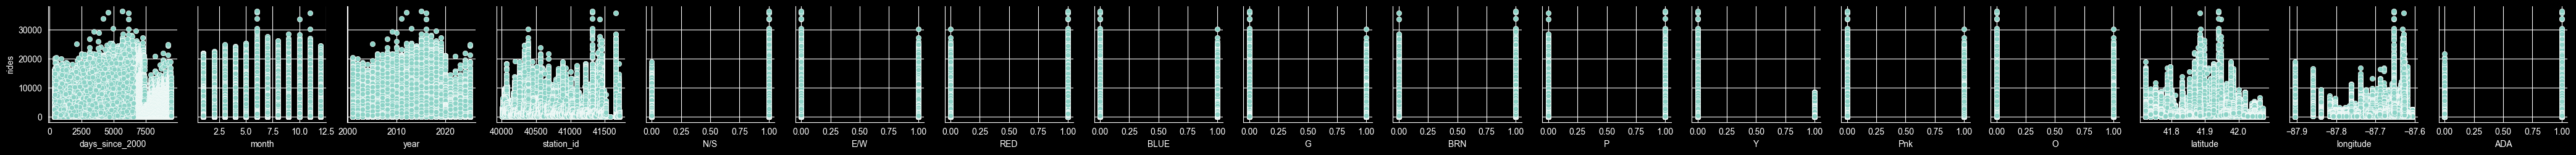

In [92]:
sns.pairplot(station_ridership, x_vars=['days_since_2000', 'month', 'year', 'station_id', 'N/S', 'E/W', 'RED', 'BLUE', 'G', 'BRN', 'P', 'Y', 'Pnk', 'O', 'latitude', 'longitude', 'ADA'], y_vars=['rides'])
plt.show()

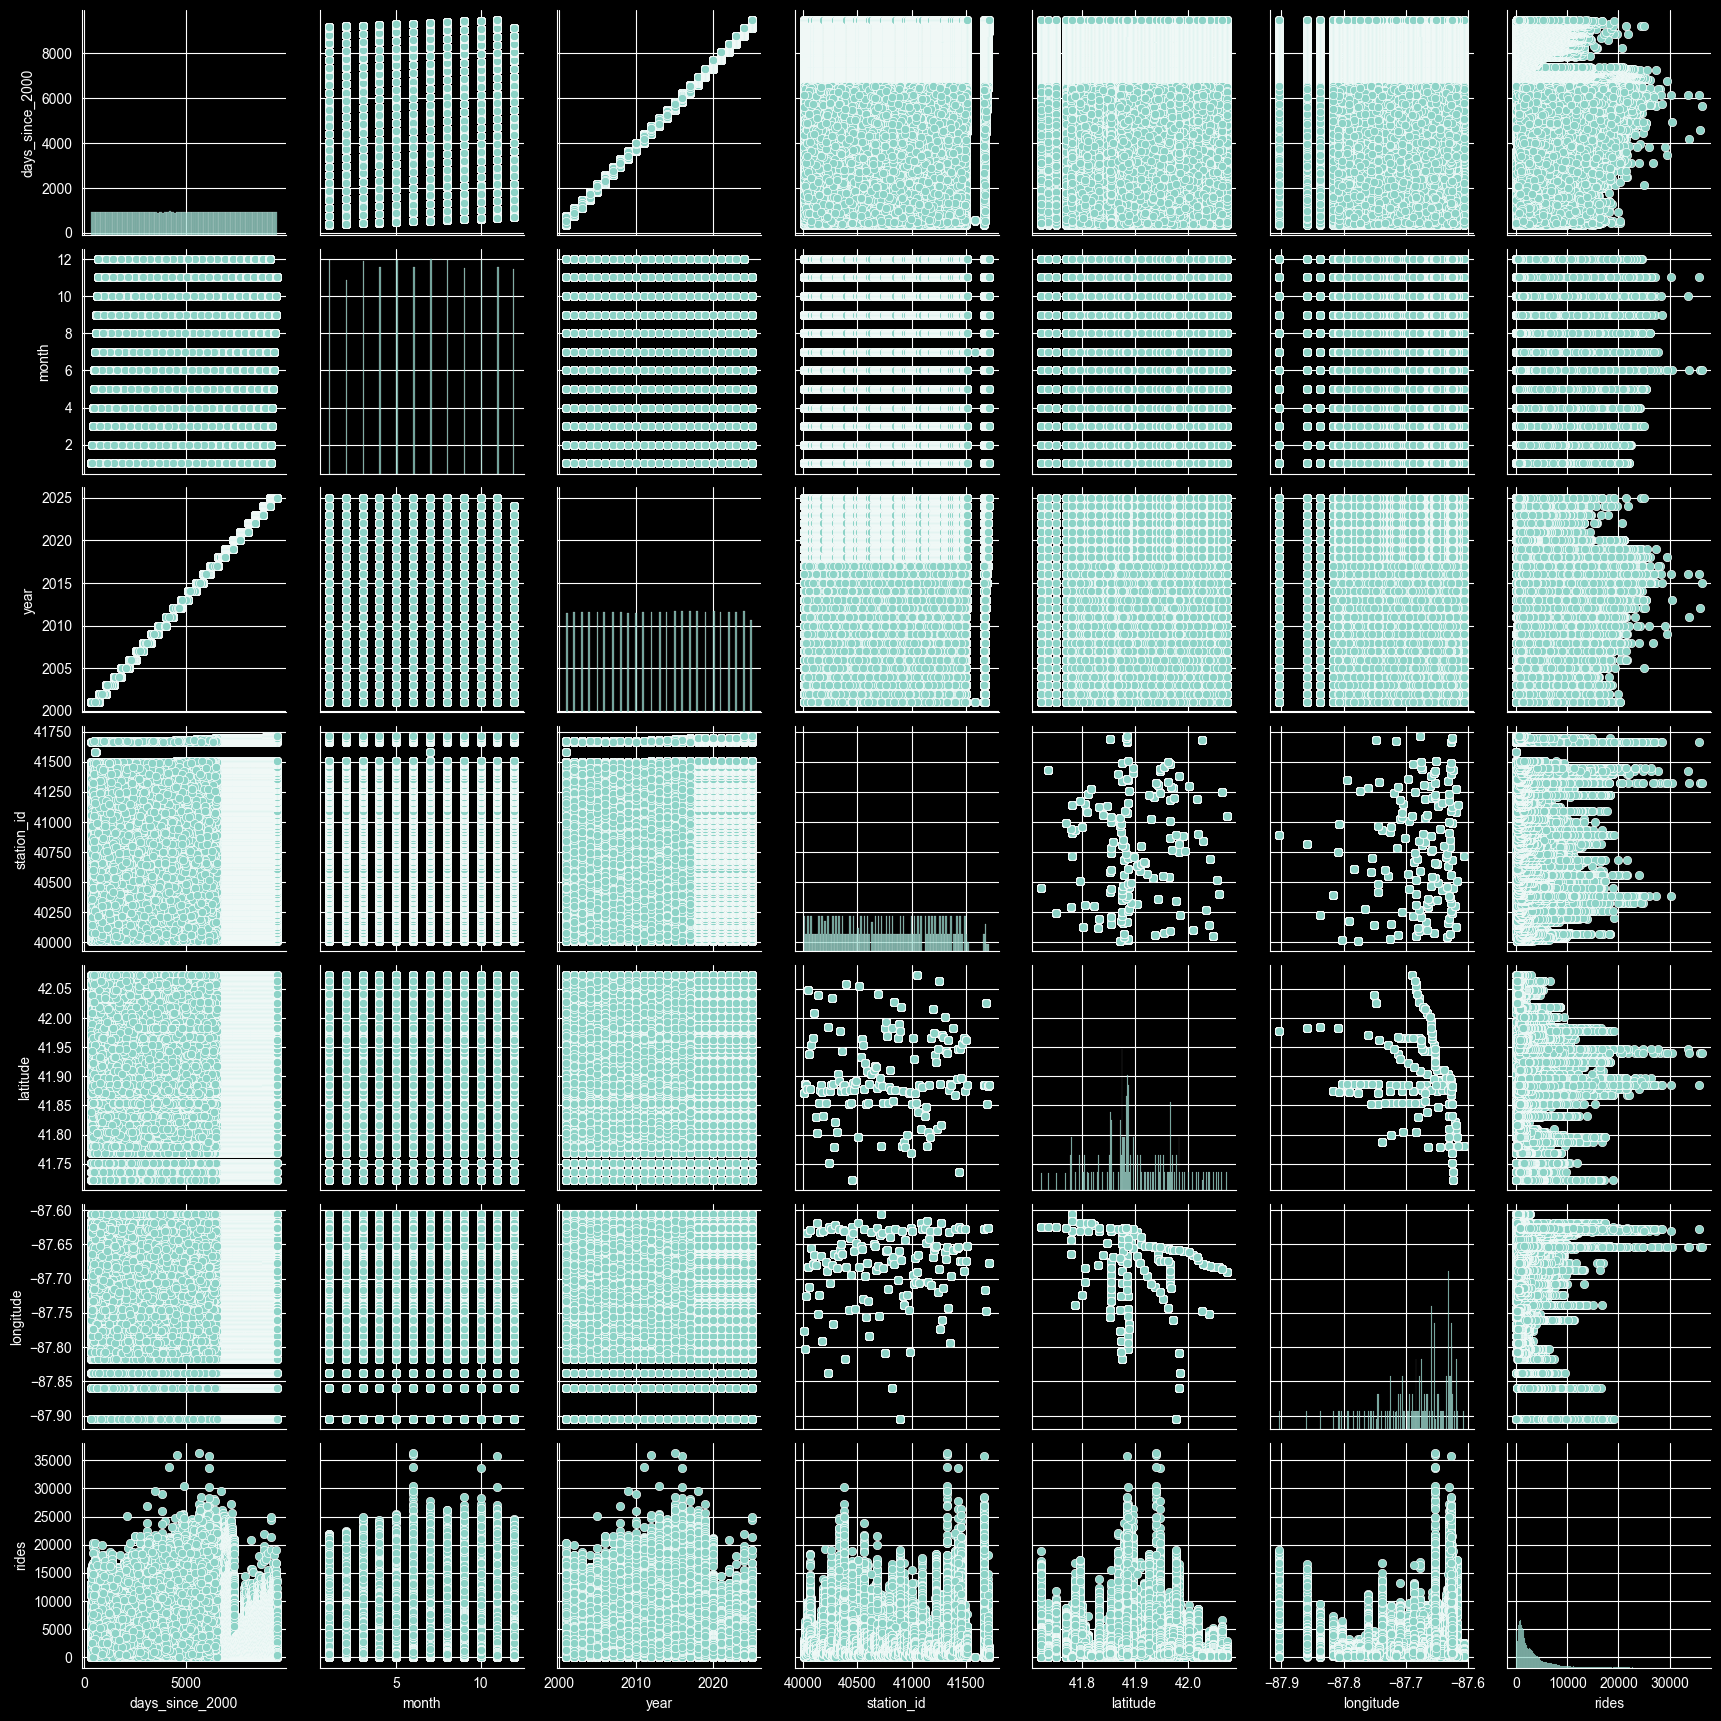

In [93]:
sns.pairplot(station_ridership[['days_since_2000', 'month', 'year', 'station_id', 'latitude', 'longitude', 'rides']])
plt.show()

In [94]:
zoning_df = pd.read_csv("resources/zoning_districts_2026.csv")

# Convert WKT strings to actual geometry objects
zoning_df['geometry'] = zoning_df['the_geom'].apply(wkt.loads)
zoning_df['ZONE_TYPE'] = zoning_df['ZONE_CLASS'].apply(lambda x: re.split(r'[-\s]+', x)[0])
# Now create the GeoDataFrame with the geometry column
zoning_gdf = gpd.GeoDataFrame(zoning_df, geometry='geometry', crs='EPSG:4326')

zone_classes = sorted(zoning_gdf['ZONE_TYPE'].unique())
for zone_class in zone_classes:
    print(f"CLASS: {zone_class}")
    print("\n")

print(zoning_gdf['geometry'])

CLASS: B1


CLASS: B2


CLASS: B3


CLASS: C1


CLASS: C2


CLASS: C3


CLASS: DC


CLASS: DR


CLASS: DS


CLASS: DX


CLASS: M1


CLASS: M2


CLASS: M3


CLASS: PD


CLASS: PMD


CLASS: PMD13


CLASS: POS


CLASS: RM


CLASS: RM4


CLASS: RM4.5


CLASS: RM5.5


CLASS: RS


CLASS: RT


CLASS: T


0        MULTIPOLYGON (((-87.72676 41.94547, -87.72737 ...
1        MULTIPOLYGON (((-87.68893 41.81577, -87.68892 ...
2        MULTIPOLYGON (((-87.67311 41.74956, -87.67311 ...
3        MULTIPOLYGON (((-87.62103 41.67592, -87.62106 ...
4        MULTIPOLYGON (((-87.66597 41.90247, -87.66601 ...
                               ...                        
14870    MULTIPOLYGON (((-87.66328 41.9241, -87.66328 4...
14871    MULTIPOLYGON (((-87.63882 41.83156, -87.63882 ...
14872    MULTIPOLYGON (((-87.66115 41.86935, -87.66124 ...
14873    MULTIPOLYGON (((-87.72035 41.8478, -87.72038 4...
14874    MULTIPOLYGON (((-87.8069 41.97748, -87.80701 4...
Name: geometry, Length: 14875, dtype: geometry


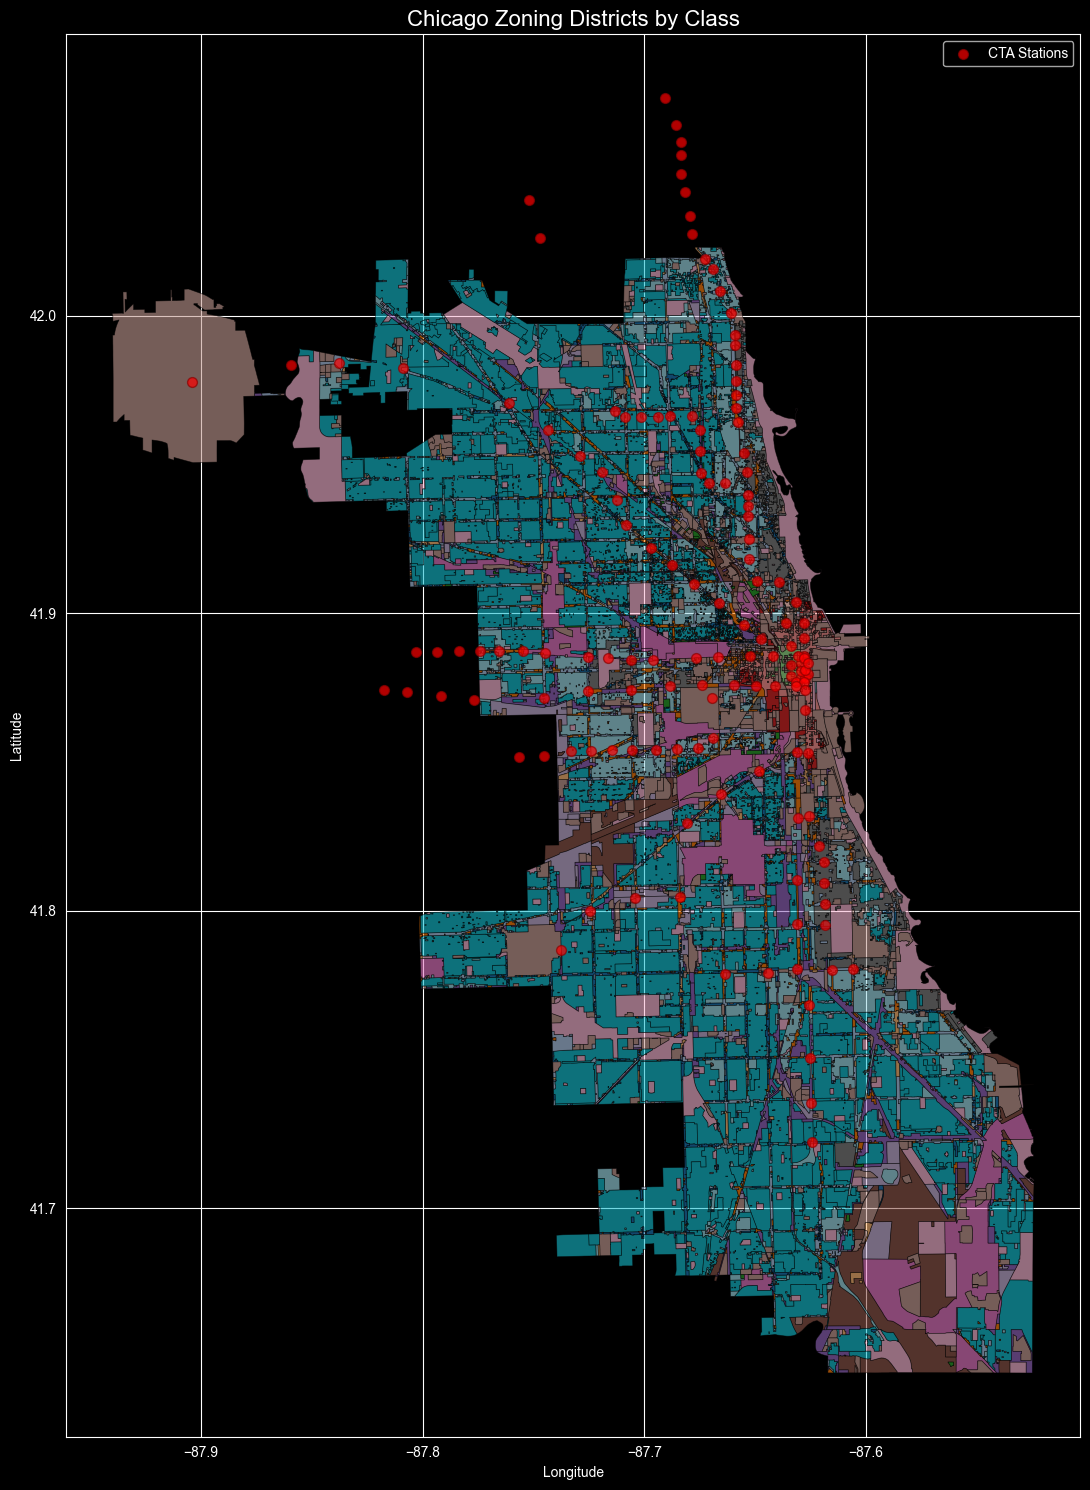

In [95]:
# Plot the zoning districts
fig, ax = plt.subplots(figsize=(15, 15))
zoning_gdf.plot(ax=ax, column='ZONE_TYPE', legend=True, cmap='tab20', alpha=0.6, edgecolor='black', linewidth=0.5)

# Add station locations
ax.scatter(si_aggregated['longitude'], si_aggregated['latitude'], 
           c='red', s=50, alpha=0.7, edgecolors='darkred', linewidth=1, 
           label='CTA Stations', zorder=5)

ax.set_title('Chicago Zoning Districts by Class', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right')
plt.tight_layout()
plt.show()

In [96]:
si_aggregated

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
139,41670,Conservatory,41.884904,-87.716523,1,0,0,1,0,0,0,0,0,0,1
140,41680,Oakton-Skokie,42.026243,-87.747221,1,0,0,0,0,0,1,0,0,1,0
141,41690,Cermak-McCormick Place,41.853115,-87.626402,1,0,0,1,0,0,0,0,0,1,0
142,41700,Washington/Wabash,41.883220,-87.626189,1,0,0,1,1,1,0,1,1,1,0


In [97]:
# Create a GeoDataFrame with station locations with shapes representing a 1 mile buffer around each station
si_gdf = gpd.GeoDataFrame(
    si_aggregated,
    geometry=gpd.points_from_xy(si_aggregated['longitude'], si_aggregated['latitude']),
    crs='EPSG:4326'
)

# Project to a projected CRS that uses meters (Chicago area: NAD83 / Illinois East)
si_gdf_projected = si_gdf.to_crs('EPSG:2790')

# Create 1-mile buffers (1 mile = 1609.34 meters)
feet_per_mile = 5280
meters_per_foot = 0.3048
meters_per_mile = feet_per_mile * meters_per_foot  # 1609.344 meters

si_gdf_projected['geometry_mile'] = si_gdf_projected.geometry.buffer(meters_per_mile)
si_gdf_projected['geometry_half_mile'] = si_gdf_projected.geometry.buffer(meters_per_mile / 2)

# WGS84 is EPSG:4326, where coordinates are in decimal degrees
# (x = longitude, y = latitude), not linear units like meters/feet.
si_gdf['geometry_mile'] = gpd.GeoSeries(
    si_gdf_projected['geometry_mile'], crs=si_gdf_projected.crs
).to_crs(si_gdf.crs)

si_gdf['geometry_half_mile'] = gpd.GeoSeries(
    si_gdf_projected['geometry_half_mile'], crs=si_gdf_projected.crs
).to_crs(si_gdf.crs)
display(si_gdf.head())

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,Y,Pnk,O,N/S,E/W,geometry,geometry_mile,geometry_half_mile
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,0,0,0,0,1,POINT (-87.77681 41.87085),"POLYGON ((-87.75743 41.87076, -87.75753 41.869...","POLYGON ((-87.76712 41.8708, -87.76717 41.8700..."
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,0,0,0,0,1,POINT (-87.80318 41.88685),"POLYGON ((-87.78379 41.88676, -87.78389 41.885...","POLYGON ((-87.79348 41.8868, -87.79353 41.8860..."
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,0,0,0,0,1,POINT (-87.7254 41.88541),"POLYGON ((-87.70601 41.88531, -87.70612 41.883...","POLYGON ((-87.71571 41.88536, -87.71576 41.884..."
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,0,1,1,1,0,POINT (-87.63374 41.87872),"POLYGON ((-87.61435 41.8786, -87.61446 41.8771...","POLYGON ((-87.62405 41.87866, -87.6241 41.8779..."
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,0,0,0,1,0,POINT (-87.68354 42.04771),"POLYGON ((-87.6641 42.0476, -87.66421 42.04618...","POLYGON ((-87.67382 42.04765, -87.67388 42.046..."


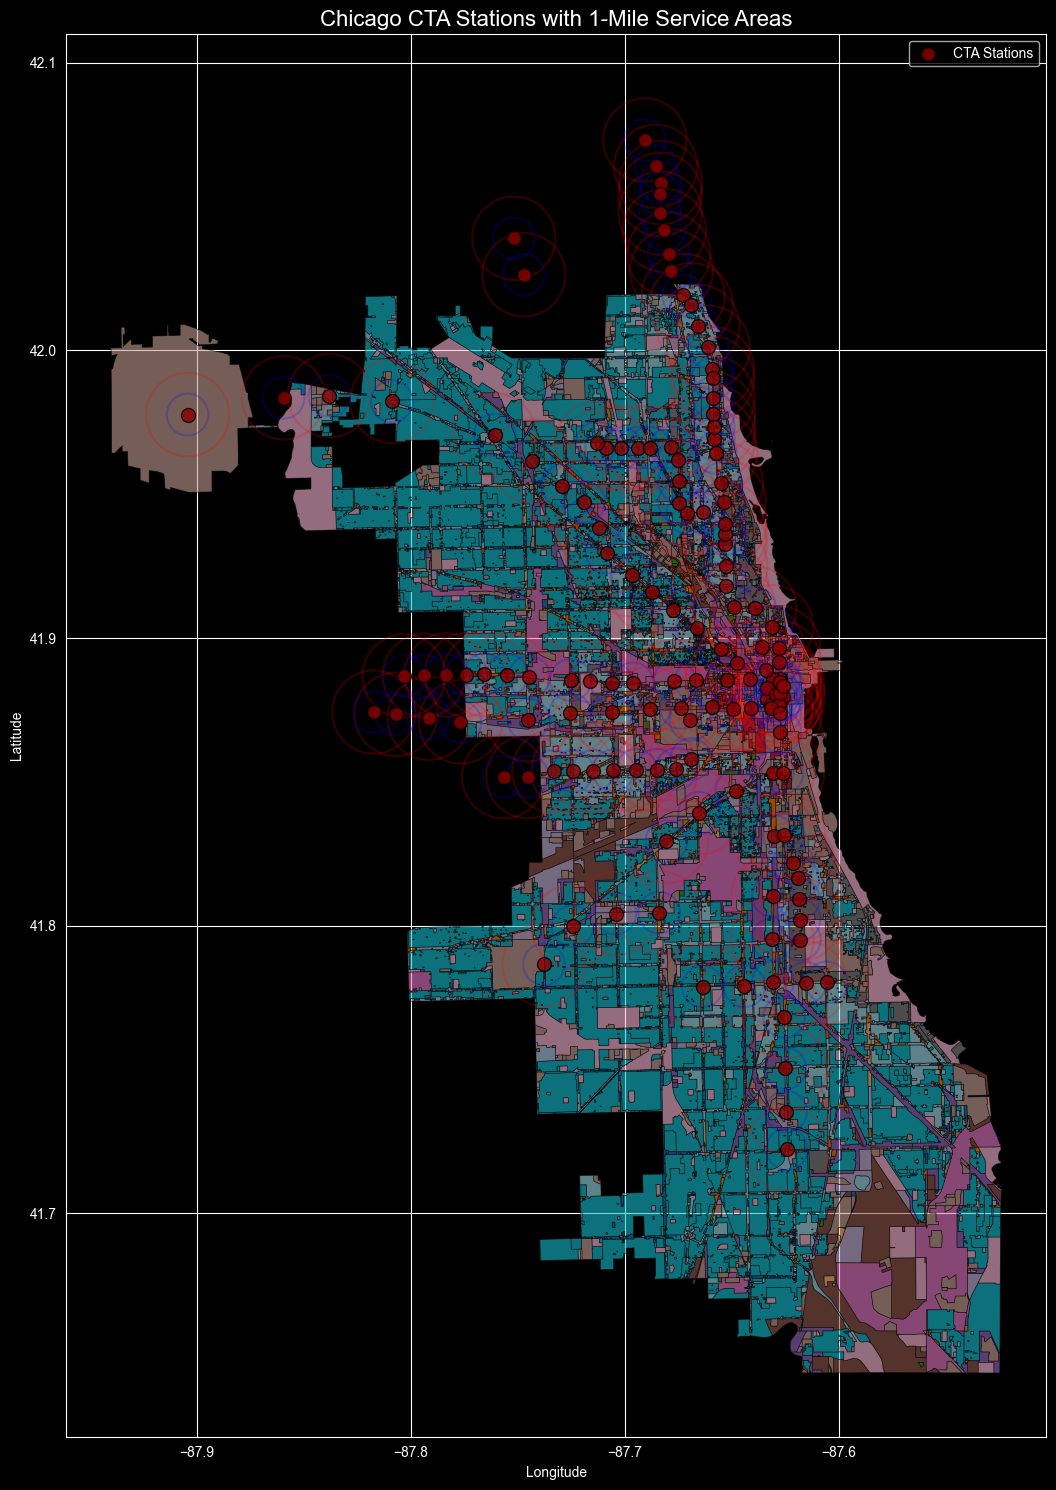

In [98]:
fig, ax = plt.subplots(figsize=(15, 15))
zoning_gdf.plot(ax=ax, column='ZONE_TYPE', legend=True, cmap='tab20', alpha=0.6, edgecolor='black', linewidth=0.5)

# Plot station points
ax.scatter(si_gdf['longitude'], si_gdf['latitude'], 
           c='darkred', s=100, alpha=0.8, edgecolors='black', linewidth=1, 
           label='CTA Stations', zorder=5)

ax.set_title('Chicago CTA Stations with 1-Mile Service Areas', fontsize=16)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.legend(loc='upper right', fontsize=10)
plt.tight_layout()


si_gdf['geometry_mile'].plot(
    ax=ax,
    facecolor='none',
    edgecolor='red',
    alpha=0.2,
    linewidth=1.5,
    zorder=4
)

si_gdf['geometry_half_mile'].plot(
    ax=ax,
    facecolor='none',
    edgecolor='blue',
    alpha=0.2,
    linewidth=1.5,
    zorder=4
)

# ax.set_ylim(miny, maxy)
# minx, miny, maxx, maxy = zoning_gdf.total_bounds
# ax.set_xlim(minx, maxx)

plt.show()

In [99]:

for zone_class in zone_classes:
    zone_polygons = zoning_gdf[zoning_gdf['ZONE_TYPE'] == zone_class]['geometry']

    mile_column_name = f"{zone_class}_mile"
    half_mile_column_name = f"{zone_class}_half_mile"
    
    si_gdf[mile_column_name] = si_gdf['geometry_mile'].apply(lambda x: zone_polygons.intersects(x).any())
    si_gdf[half_mile_column_name] = si_gdf['geometry_half_mile'].apply(lambda x: zone_polygons.intersects(x).any())

si_gdf.head()

,MAP_ID,STATION_NAME,latitude,longitude,ADA,RED,BLUE,G,BRN,P,...,RM4.5_mile,RM4.5_half_mile,RM5.5_mile,RM5.5_half_mile,RS_mile,RS_half_mile,RT_mile,RT_half_mile,T_mile,T_half_mile
0,40010,Austin,41.870851,-87.776812,0,0,1,0,0,0,...,False,False,False,False,True,True,True,True,False,False
1,40020,Harlem/Lake,41.886848,-87.803176,1,0,0,1,0,0,...,False,False,False,False,False,False,False,False,False,False
2,40030,Pulaski,41.885412,-87.725404,1,0,0,1,0,0,...,False,False,False,False,True,True,True,True,False,False
3,40040,Quincy/Wells,41.878723,-87.633740,1,0,0,0,1,1,...,False,False,False,False,False,False,True,False,True,False
4,40050,Davis,42.047710,-87.683543,1,0,0,0,0,1,...,False,False,False,False,False,False,False,False,False,False


In [100]:
ridership_with_zoning = pd.merge(station_ridership, si_gdf.drop(columns=['geometry', 'geometry_mile', 'geometry_half_mile']), left_on='MAP_ID', right_on='MAP_ID', how='left')

ridership_with_zoning.head()

,station_id,stationname,date,daytype,rides,MAP_ID,STATION_NAME_x,latitude_x,longitude_x,ADA_x,...,RM4.5_mile,RM4.5_half_mile,RM5.5_mile,RM5.5_half_mile,RS_mile,RS_half_mile,RT_mile,RT_half_mile,T_mile,T_half_mile
0,41280,Jefferson Park,2017-12-22,W,6104,41280.0,Jefferson Park,41.970634,-87.760892,1.0,...,False,False,False,False,True,True,True,True,False,False
1,41000,Cermak-Chinatown,2017-12-18,W,3636,41000.0,Cermak-Chinatown,41.853206,-87.630968,1.0,...,False,False,False,False,True,False,True,True,True,True
2,40280,Central-Lake,2017-12-02,A,1270,40280.0,Central,41.887389,-87.765650,1.0,...,False,False,False,False,True,True,True,True,False,False
3,40140,Dempster-Skokie,2017-12-19,W,1759,40140.0,Dempster-Skokie,42.038951,-87.751919,1.0,...,False,False,False,False,False,False,False,False,False,False
4,40690,Dempster,2017-12-03,U,499,40690.0,Dempster,42.041655,-87.681602,0.0,...,False,False,False,False,False,False,False,False,False,False


In [102]:
# Build a modeling dataset from ridership_with_zoning
model_df = ridership_with_zoning.copy()

# Keep core temporal/transit features + zoning proximity flags
base_features = [
    'days_since_2000', 'post_shutdown', 'month', 'season_Spring', 'season_Summer', 'season_Winter', 'year', "latitude_x", "longitude_x", 'ADA_x', 'RED_x', 'BLUE_x', 'G_x', 'BRN_x', 'P_x', 'Y_x', 'Pnk_x', 'O_x',
    'N/S_x', 'E/W_x'
]
zoning_features = [c for c in model_df.columns if c.endswith('_mile') or c.endswith('_half_mile')]
feature_cols = [c for c in base_features if c in model_df.columns] + zoning_features

X = model_df[feature_cols].copy()
y = model_df['rides'].copy()

# Add daytype as dummy variables
daytype_dummies = pd.get_dummies(model_df['daytype'], prefix='daytype', drop_first=True, dtype=int)
X = pd.concat([X, daytype_dummies], axis=1)

# Convert boolean columns to int
bool_cols = X.select_dtypes(include='bool').columns
X[bool_cols] = X[bool_cols].astype(int)

# Force all predictors/target to numeric for statsmodels compatibility
X = X.apply(pd.to_numeric, errors='coerce')
y = pd.to_numeric(y, errors='coerce')

# Drop rows with any missing values in features/target
valid_mask = X.notna().all(axis=1) & y.notna()
X = X.loc[valid_mask]
y = y.loc[valid_mask]

# Optional sampling for speed on very large dataset
sample_n = min(200_000, len(X))
sample_idx = X.sample(n=sample_n, random_state=42).index
X = X.loc[sample_idx]
y = y.loc[sample_idx]

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X.astype(float), y.astype(float), test_size=0.2, random_state=42
)

# Fit OLS model
X_train_const = sm.add_constant(X_train, has_constant='add')
X_test_const = sm.add_constant(X_test, has_constant='add')

ols_model = sm.OLS(y_train, X_train_const).fit()

# Predict and evaluate
y_pred = ols_model.predict(X_test_const)

rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")
print(f"R²:   {r2:.4f}")

# Full statistical summary
print(ols_model.summary())

RMSE: 1,644.81
MAE:  1,165.97
R²:   0.7033
                            OLS Regression Results                            
Dep. Variable:                  rides   R-squared:                       0.703
Model:                            OLS   Adj. R-squared:                  0.702
Method:                 Least Squares   F-statistic:                     5640.
Date:                Sun, 22 Feb 2026   Prob (F-statistic):               0.00
Time:                        14:42:17   Log-Likelihood:            -1.4126e+06
No. Observations:              160000   AIC:                         2.825e+06
Df Residuals:                  159932   BIC:                         2.826e+06
Df Model:                          67                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------